In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
from qutip import *
import numpy as np
from qutip import basis, spin_Jy, spin_Jz
from qutip import jmat, basis, ket2dm, commutator
from scipy.optimize import curve_fit
%matplotlib inline
import scipy as sp
from io import BytesIO
from PIL import Image
from IPython.display import display
from ipywidgets import interact, IntSlider
from MewtwoDataProcess import *
from tomo_plot_hammer import *
import sys
sys.path.append('Analysis')
from Analysis import *
from fit_toolbox import *


In [2]:
SimPath = '/Users/sean/Code/MewtwoMegaEvo-develop/Playground'

In [3]:
j=7/2

Jx = spin_Jx(j)
Jy = spin_Jy(j)
Jz = spin_Jz(j)

Ix = jmat(j,'x')
Iy = jmat(j,'y')
Iz = jmat(j,'z')

Ip = jmat(j, '+')
Im = jmat(j, '-')

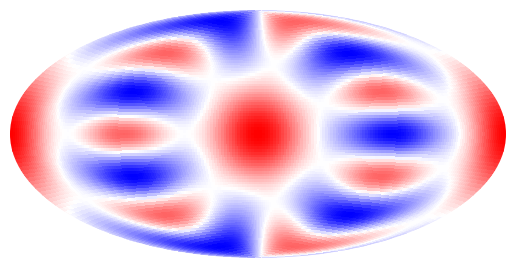

In [4]:
psi = basis(8,0)
H0 = (np.pi/(2)) * Jx
S = 7/2
U0 = (-1j * H0 * 1).expm()
kappa = S*np.pi
Upulse = (-1j * (kappa/(2.0 * S)) * (Jz**2)).expm()
tomo_plot_hammer(Upulse*U0*psi, 'w')

# Quantum Kicked top Hamitlonian

In [5]:
def kicked_dynamics(psi_initial, tau, kappa, j, N = 1, order=2):
    # Spin is 7/2 => dimension is 8
    S = j
    dim = int(2*S + 1)
    # Parameters
    chi = kappa/2

    # QuTiP spin operators
    Jx = spin_Jx(S)
    Jy = spin_Jy(S)
    Jz = spin_Jz(S)

    # Free Hamiltonian H0
    H0 = (np.pi/(2)) * -Jy
    # Precompute the free evolution operator for time tau
    U0 = (-1j * H0 * tau).expm()

    # Larmor pulse unitary (instantaneous)
    Ularmor = (-1j * chi * (Jz)).expm()

    # Precompute the pulse unitary (instantaneous)
    # Upulse = (-1j * (kappa/(2.0 * S)) * (Jz**2)).expm()
    Upulse = (-1j * Jz ** order * kappa/ (order*S **(order-1))).expm()
                
    
    # Evolve the state stroboscopically
    psi = psi_initial          # Start with the prepared state
    psi_list = [psi]           # Store states after each pulse
    overlap_list = [psi.overlap(psi_initial)]  # Overlap with the initial state
    entropy_list  = [qudit_linear_entropy(psi, j)]
    exp_list = [qudit_exp(psi, j)]

    for n in range(N):
        # 1) Free evolution for time tau
        psi = U0 * psi

        # 2) Instantaneous pulse
        psi = Upulse * psi
        # psi = Ularmor * psi

        # Store the new state and its overlap with the initial state
        psi_list.append(psi)
        overlap_list.append(psi.overlap(psi_initial))
        entropy_list.append(qudit_linear_entropy(psi, j))
        exp_list.append(qudit_exp(psi, j))

    return psi_list, overlap_list, entropy_list

In [6]:
def qudit_linear_entropy(psi, j):
    Ix = jmat(j,'x')
    Iy = jmat(j,'y')
    Iz = jmat(j,'z')
    entropy = 1/2*(1 - (expect(Ix, psi)**2 + expect(Iy, psi)**2 + expect(Iz, psi)**2)/(j)**2)
    return entropy

In [7]:
def qudit_exp(psi, j):
    Ix = jmat(j,'x')
    Iy = jmat(j,'y')
    Iz = jmat(j,'z')
    exp_x = expect(Ix, psi)
    exp_y = expect(Iy, psi)
    exp_z = expect(Iz, psi)
    exp_array = [exp_x, exp_y, exp_z]
    return exp_array

In [8]:
def Displace(theta, phi, psi, j):
    spin_dim = j

    Ip = jmat(spin_dim, '+')
    Im = jmat(spin_dim, '-')
        
    D = (theta/2*(np.exp(1j*phi)*Im - np.exp(-1j*phi)*Ip)).expm()
    return D * psi
    
def initial_state(theta, phi, j):
    dim = int(2*j + 1)
    psi0 = basis(dim, 0)
    psi_normal = Displace(theta, phi, psi0, j)

    return psi_normal

In [9]:
def sample_initial_states(n_points):
    initial_state_list = []
    
    phis = np.linspace(-np.pi, np.pi, 2 * n_points)
    thetas = np.linspace(0, np.pi, n_points)

    for theta in thetas:
        for phi in phis:
            state = initial_state(theta, phi)
            initial_state_list.append(state)
    
    return initial_state_list

In [10]:
def Hz_order(kappa, order):
    H = kappa * (Iz) **(order) / (order * (7/2) ** (order -1 ))
    return H

# Phase map (Linear entropy color map)

In [11]:
def analyze_entropy_distribution(num_theta, num_phi, tau, kappa, j, N):
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.interpolate import griddata

    # Step 1: Generate initial states with all (theta, phi) combinations
    initial_states_with_coords = []
    thetas = np.linspace(0, np.pi, num_theta)
    phis = np.linspace(-np.pi, np.pi, num_phi)

    for theta in thetas:
        for phi in phis:
            state = initial_state(theta, phi, j)
            initial_states_with_coords.append((theta, phi, state))

    # Step 2: Time evolve and extract final entropies
    entropies = []
    theta_vals = []
    phi_vals = []
    exp_list = []

    for theta, phi, state in initial_states_with_coords:
        state_t, _, entropy_t = kicked_dynamics(state, tau, kappa, j, N)
        final_entropy = entropy_t[-1]  # Or use np.mean(entropy_t[-20:]) if averaging preferred

        entropies.append(final_entropy)

        theta_vals.append(theta)
        phi_vals.append(phi)
        

    # Step 3: Convert to 2D grid for plotting
    theta_vals = np.array(theta_vals)
    phi_vals = np.array(phi_vals)
    entropies = np.array(entropies)

    grid_theta, grid_phi = np.meshgrid(thetas, phis)
    grid_entropy = griddata(
        (theta_vals, phi_vals),
        entropies,
        (grid_theta, grid_phi),
        method='cubic'
    )

    # Step 4: Plot
    plt.figure(figsize=(8, 6))
    im = plt.pcolormesh(grid_phi, grid_theta, grid_entropy, shading='auto', cmap='bwr')
    # plt.xlabel("Phi (φ) [-π, 0]")
    # plt.ylabel("Theta (θ) [0, π/2]")
    plt.title(f'Quantum Phase Space — κ={kappa:.2f}, τ={tau:.2f}')
    plt.colorbar(im, label='Entropy')
    plt.show()

    return entropies


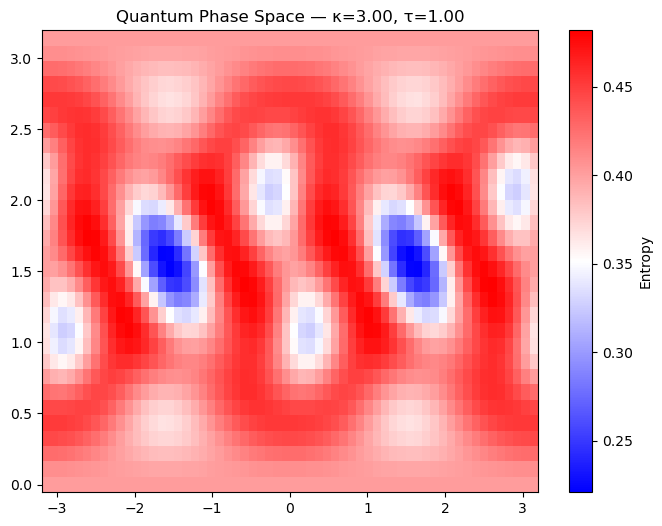

In [12]:
entropies = analyze_entropy_distribution(num_theta=30, num_phi=60, tau=1, kappa=3, j=3.5, N = 4)

# Dynamical Tunneling Simulation

In [ ]:
spin = 3.5
psi_initial = initial_state(np.pi-2.25, -0.625, j=spin)
# psi_initial = initial_state(0, 0, j=spin)
n_kicks = 16 
k = 3
psi_lst = kicked_dynamics(psi_initial, tau=1, kappa=k, j=spin, N = n_kicks)
#### put figures into a slider
def show_frame(kick):
    tomo_plot_hammer(psi_lst[0][kick], "h")  # This creates and shows the figure
interact(show_frame, kick=IntSlider(min=0, max=n_kicks, step=1, value=0, layout={'width': '800px'}))

interactive(children=(IntSlider(value=0, description='kick', layout=Layout(width='800px'), max=16), Output()),…

<function __main__.show_frame(kick)>

In [14]:
# tomo_plot_hammer(psi_initial, "h") 
rho_initial = psi_initial.proj()
# np.array(rho_initial)

## Tunnel period vs Subspace 

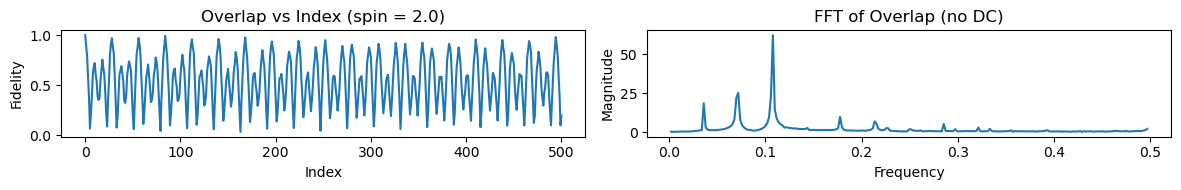

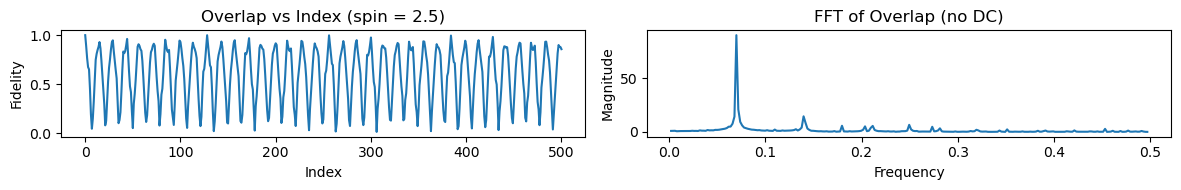

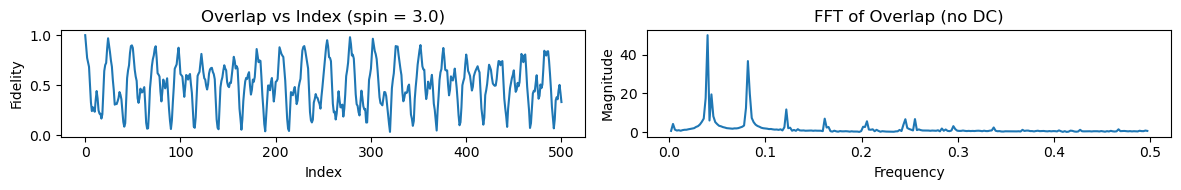

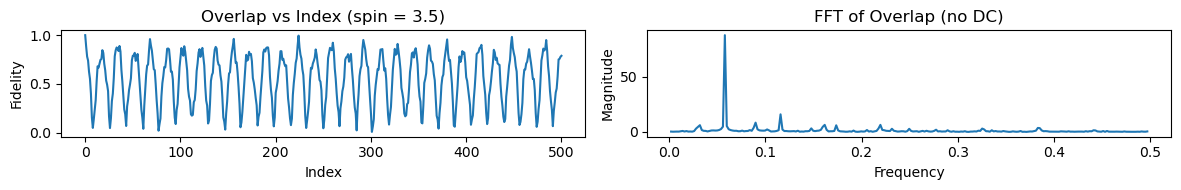

In [15]:

from qutip import fidelity  # Assuming you're using qutip for fidelity
# spin = 3.5
def tunnel(spin):
    psi_initial = initial_state(np.pi-2.25, -0.625, j=spin)
    n_kicks = 500
    psi_lst = kicked_dynamics(psi_initial, tau=1, kappa=3, j=spin, N = n_kicks)
    #### put figures into a slider
    
    data = psi_lst[0]
    overlap = np.zeros(len(data))
    
    for i in range(len(data)):
        overlap[i] = fidelity(data[0], data[i])
    
    # Plot 1: Overlap over time
    plt.figure(figsize=(12,2))
    
    plt.subplot(1, 2, 1)
    plt.plot(np.arange(len(data)), overlap)
    plt.title(f"Overlap vs Index (spin = {spin})")
    plt.xlabel("Index")
    plt.ylabel("Fidelity")
    
    # Compute FFT
    fft_vals = np.fft.fft(overlap)
    fft_freqs = np.fft.fftfreq(len(overlap))
    
    # Remove DC component (index 0)
    fft_vals_no_dc = fft_vals[1:len(fft_vals)//2]
    fft_freqs_no_dc = fft_freqs[1:len(fft_vals)//2]
    
    # Plot 2: FFT Magnitude without DC
    plt.subplot(1, 2, 2)
    plt.plot(fft_freqs_no_dc, np.abs(fft_vals_no_dc))
    plt.title("FFT of Overlap (no DC)")
    plt.xlabel("Frequency")
    plt.ylabel("Magnitude")
    
    plt.tight_layout()
    plt.show()
for i in np.arange(2,4, 0.5):
    tunnel(i)

/var/folders/t_/r65y_13j39526wrmgrvth29h0000gn/T/ipykernel_22407/2347200110.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


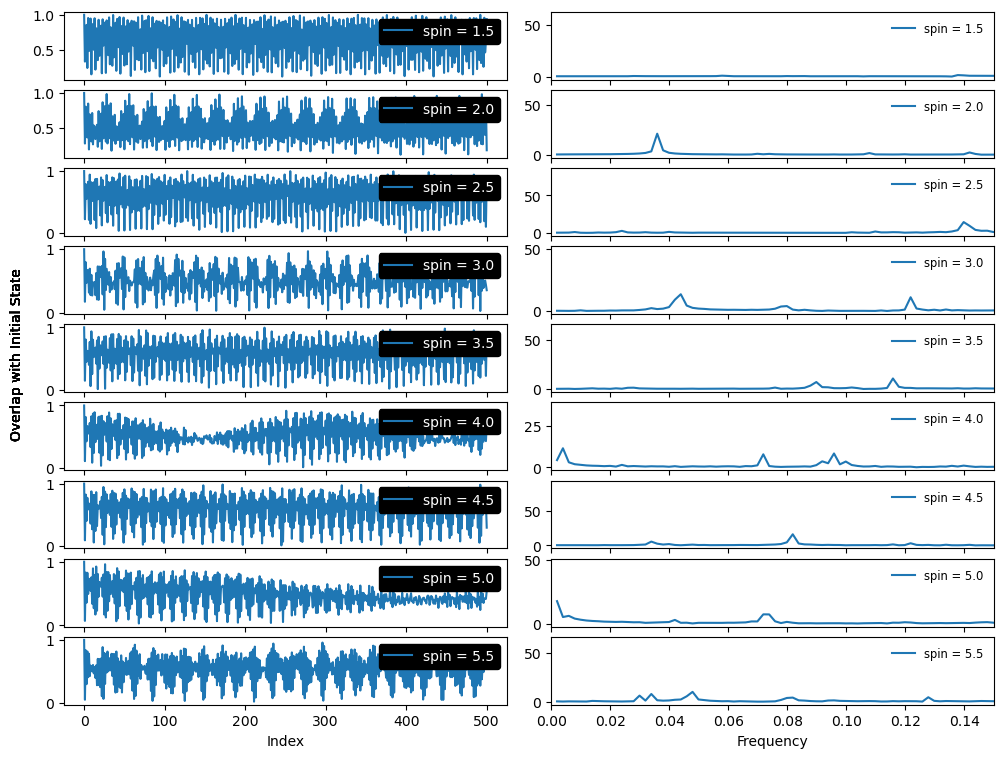

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import fidelity  # Assuming you're using qutip for fidelity

def tunnel(spin):
    psi_initial = initial_state(2.25, 0.7, j=spin)
    
    n_kicks = 500
    psi_lst = kicked_dynamics(psi_initial, tau=1, kappa=3, j=spin, N=n_kicks)
    data = psi_lst[0]
    
    overlap = np.zeros(len(data))
    for i in range(len(data)):
        overlap[i] = fidelity(data[0], data[i])

    fft_vals = np.fft.fft(overlap)
    fft_freqs = np.fft.fftfreq(len(overlap))
    fft_vals_no_dc = fft_vals[1:len(fft_vals)//2]
    fft_freqs_no_dc = fft_freqs[1:len(fft_vals)//2]

    return overlap, fft_freqs_no_dc, np.abs(fft_vals_no_dc)

# Spin values
spin_values = np.arange(1.5, 6, 0.5)
n_rows = len(spin_values)

# Create figure
fig, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=(12, 1 * n_rows), sharex='col', gridspec_kw={'hspace': 0.15})
plt.subplots_adjust(hspace=0.05, wspace=0.1)

for i, spin in enumerate(spin_values):
    overlap, freqs, fft_mag = tunnel(spin)

    # Left column: overlap
    ax1 = axes[i, 0]
    ax1.plot(np.arange(len(overlap)), overlap, label=f"spin = {spin}")
    # ax1.legend(loc="upper right", fontsize="small", frameon=False)
    ax1.legend(
    loc="upper right",
    fontsize=10,
    facecolor="black",
    edgecolor="black",
    framealpha=1.0,       # fully opaque
    labelcolor="white"    # this works in Matplotlib ≥ 3.5
)
    # ax1.set_ylabel("Fidelity")
    fig.text(0.08, 0.5, 'Overlap with Initial State', va='center', rotation='vertical', fontsize=10,fontweight='light')
    if i == n_rows - 1:
        ax1.set_xlabel("Index")
    else:
        ax1.tick_params(labelbottom=False)  # hide x-ticks except for bottom row

    # Right column: FFT
    ax2 = axes[i, 1]
    ax2.plot(freqs, fft_mag, label=f"spin = {spin}")
    ax2.set_xlim(0, 0.15)
    ax2.legend(loc="upper right", fontsize="small", frameon=False)

    if i == n_rows - 1:
        ax2.set_xlabel("Frequency")
    else:
        ax2.tick_params(labelbottom=False)

plt.tight_layout()
plt.show()


# Mewtwo Analysis


## Global rotation Rabi pi time calibration 

In [13]:
# DynamicalTunnelingSimulation20251202172224 Fitted period: 3.7560 ms global pi time 

In [14]:
3.7560e-3 / 4

0.000939

In [15]:
1e6/12.25

81632.6530612245

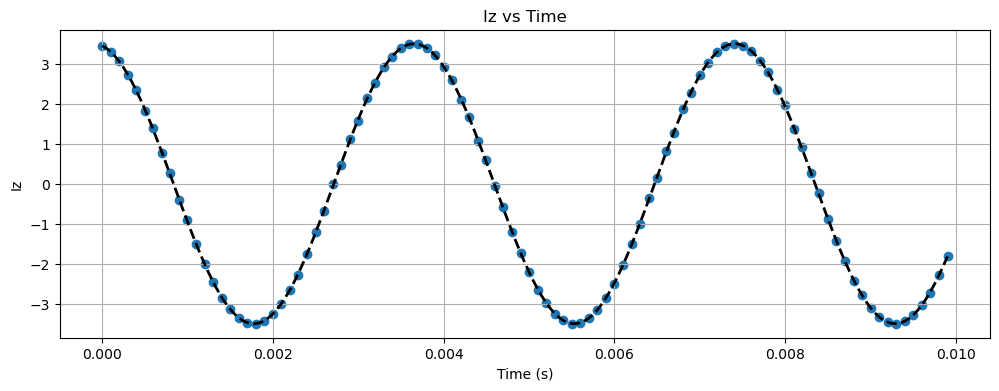

0.0037560173952341314

In [16]:
# Iz vs time (kicks)

data = LoadMewtwoData(SimPath + r'/sim_results/DynamicalTunnelingSimulation20251202172224')
ds = data.__dict__
Iz_array = ds['meas_marker'].__dict__['Iz'].__dict__['rhoI1']
kick_dt = 1e-4  # seconds per kick from       "pulse_width" in gate_config.json

n_kicks = np.arange(len(Iz_array))
time_s = n_kicks * kick_dt   # convert kicks → seconds
fit = SineFit(xvals=time_s, ydata=Iz_array)

plt.figure(figsize=(12,4))

# Plot raw data
plt.scatter(time_s, Iz_array, marker='o', label='Iz data')

# Plot fit
fit.add_to_plot(plt, label='Sine fit')

plt.xlabel('Time (s)')
plt.ylabel('Iz')
plt.title('Iz vs Time')
plt.grid(True)
plt.show()

two_pi_time = 1/fit.fit_result.params['frequency'].value
two_pi_time

In [17]:
Jz22=np.array([ [0.540062,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000],
                [0.000000,0.077152,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000],
                [0.000000,0.000000,-0.231455,0.000000,0.000000,0.000000,0.000000,0.000000],
                [0.000000,0.000000,0.000000,-0.385758,0.000000,0.000000,0.000000,0.000000],
                [0.000000,0.000000,0.000000,0.000000,-0.385758,0.000000,0.000000,0.000000],
                [0.000000,0.000000,0.000000,0.000000,0.000000,-0.231455,0.000000,0.000000],
                [0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.077152,0.000000],
                [0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.540062]])


## Dynamical tunneling

In [18]:
# Original glb 2pi time 1.875e-3

In [19]:
data = LoadMewtwoData(SimPath + r'/sim_results/DynamicalTunnelingSimulation20251204155503') 
ds = data.__dict__
n_kick = ds['rho_marker'].__dict__['Iz'].__dict__['rhoI1'].shape[2]
def show_frame(kick):
    tomo_plot_hammer(Qobj(ds['rho_marker'].__dict__['Iz'].__dict__['rhoI1'][:,:,kick]),'h')  # This creates and shows the figure
interact(show_frame, kick=IntSlider(min=0, max=n_kick-1, step=1, value=0, layout={'width': '800px'}))

interactive(children=(IntSlider(value=0, description='kick', layout=Layout(width='800px'), max=19), Output()),…

<function __main__.show_frame(kick)>

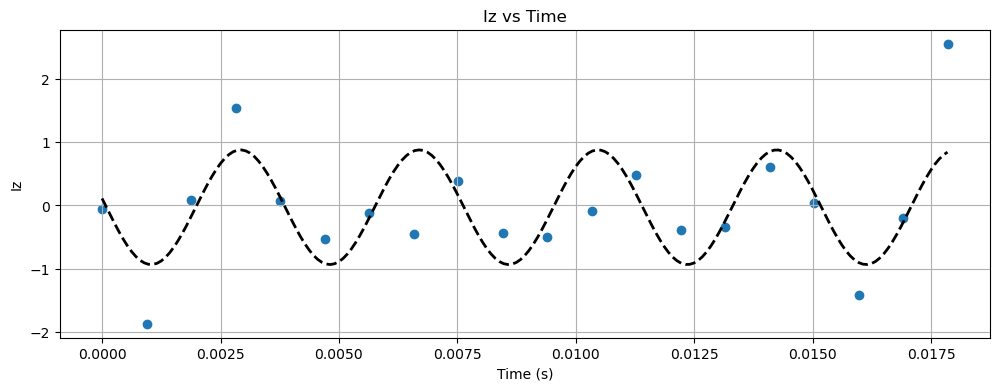

0.0037720543284397176

In [25]:
# Iz vs time (kicks)

Iz_array = ds['meas_marker'].__dict__['Iz'].__dict__['rhoI1']
kick_dt = 0.000939  # seconds per kick from       "pulse_width": in gate_config.json

n_kicks = np.arange(len(Iz_array))
time_s = n_kicks * kick_dt   # convert kicks → seconds
fit = SineFit(xvals=time_s, ydata=Iz_array)

plt.figure(figsize=(12,4))

# Plot raw data
plt.scatter(time_s, Iz_array, marker='o', label='Iz data')

# Plot fit
fit.add_to_plot(plt, label='Sine fit')

plt.xlabel('Time (s)')
plt.ylabel('Iz')
plt.title('Iz vs Time')
plt.grid(True)
plt.show()

two_pi_time = 1/fit.fit_result.params['frequency'].value
two_pi_time

In [26]:
# [X-P($K*A/7,T)-M]^20

## Dynamical Tunneling with noise

In [27]:
data = LoadMewtwoData(SimPath + r'/sim_results/DynamicalTunnelingSimulation20251203173354') # with noise, WhiteNoise_amp_7_alpha_0_samp_1us
ds = data.__dict__
# ds['gate_config'].__dict__['gate_defs'][0]
rho_kappas = ds['rho_marker'].__dict__['Iz'].__dict__['rhoI1']
print(rho_kappas.shape[0], 'kappa values')

my_kappa_index = 3
n_kick = rho_kappas[my_kappa_index].shape[2]
def show_frame(kick):
    tomo_plot_hammer(Qobj(rho_kappas[my_kappa_index][:,:,kick]),'h')  # This creates and shows the figure
interact(show_frame, kick=IntSlider(min=0, max=n_kick-1, step=1, value=0, layout={'width': '800px'}))

4 kappa values


interactive(children=(IntSlider(value=0, description='kick', layout=Layout(width='800px'), max=11), Output()),…

<function __main__.show_frame(kick)>

## Dynamical Tunneling while off resonance

In [28]:
data = LoadMewtwoData(SimPath + r'/sim_results/DynamicalTunnelingSimulation20251204171858') 
ds = data.__dict__
n_kick = ds['rho_marker'].__dict__['Iz'].__dict__['rhoI1'].shape[2]
def show_frame(kick):
    tomo_plot_hammer(Qobj(ds['rho_marker'].__dict__['Iz'].__dict__['rhoI1'][:,:,kick]),'h')  # This creates and shows the figure
interact(show_frame, kick=IntSlider(min=0, max=n_kick-1, step=1, value=0, layout={'width': '800px'}))

interactive(children=(IntSlider(value=0, description='kick', layout=Layout(width='800px'), max=19), Output()),…

<function __main__.show_frame(kick)>